
# Lab 5: Scrodinger equation with FDM

 **Exercise** : Solve the radial Schrodinger for Hydrogen atom with FDM

 ### Hydrogen radial equation

The H atom has an electron of mass $m$ a $r$ distance to the pronton. The potential energy is given by

$U(r)= -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}$

The Schrodinger's equation for this system is

$$
-\dfrac{\hbar^2}{2m}\nabla^2 \psi(\vec{r}) + -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}\psi(\vec{r})= E\,\psi(\vec{r})$$

Nota: el siguiente código markdown fue escrito por una IA, el procedimiento que se muestra fue hecho en mi tablet paso por paso y sin el uso de IA. La única utilización de IA en este caso fue para hacer el traspaso a código Latex, el cual no considero merezca mi atención en este laboratorio como para desarrollarlo todo por mi cuenta.


$$-\frac{\hbar^2}{2m}\nabla^2\Psi(\vec{r}) - \frac{e^2}{4\pi\epsilon_0}\frac{1}{r}\Psi(\vec{r}) = E\Psi(\vec{r})$$

Si definimos $\vec{r}$ y $\nabla^2$ en coordenadas esféricas:

$\Rightarrow$ Se debe considerar $l=0$, $m=0$. $Y_0^0 = \dfrac{1}{\sqrt{4\pi}}$

Solo se encuentra $\Psi_{100}$, $\Psi_{200}$, $\Psi_{300}$. Las demás no.

Digamos que $\Psi(\vec{r}) = R(r)T(\theta)P(\phi)$, el laplaciano en coordenadas esféricas es:

$$\nabla^2\Psi = \frac{1}{r^2}\frac{\partial}{\partial r}\left(r^2\frac{\partial \Psi}{\partial r}\right) + \frac{1}{r^2\sin\theta}\frac{\partial}{\partial \theta}\left(\sin\theta\frac{\partial \Psi}{\partial \theta}\right) + \frac{1}{r^2\sin\theta}\frac{\partial^2 \Psi}{\partial \phi^2}$$

$$-\frac{\hbar^2}{2m}\left(\frac{1}{r^2}\frac{\partial}{\partial r}\left(TP\,r^2\frac{dR}{dr}\right) + \frac{1}{r^2\sin\theta}\frac{\partial}{\partial\theta}\left(RP\sin\theta\frac{dT}{d\theta}\right) + \frac{RT}{r^2\sin^2\theta}\frac{d^2P}{d\phi^2}\right) - \frac{e^2}{4\pi\epsilon_0}\cdot TP\cdot\frac{1}{r}R = E\,RTP$$

Como solamente queremos resolver la parte radial, $T$ y $P$ son constantes, entonces:

$$\Rightarrow -\frac{\hbar^2}{2m}\cdot\frac{1}{r^2}\cdot\frac{1}{R}\frac{d}{dr}\left(r^2\frac{dR}{dr}\right) - \frac{e^2}{4\pi\epsilon_0 r} = E$$

$$\Rightarrow -\frac{\hbar^2}{2m}\left(\frac{2}{r}\frac{dR}{dr} + \frac{d^2R}{dr^2}\right) - \frac{e^2}{4\pi\epsilon_0 r}R = ER$$

$$R(0) = 0, \quad R(r\to\infty) = 0$$

Sugerencia profesor en clase: pasar $E$ a eV para no tratar con números pequeños.

### Sustitución $u(r) = rR(r)$

Hagamos $u(r) = rR(r) \iff R(r) = \dfrac{u(r)}{r}$ para simplificar los cálculos.

$$R' = \frac{u'}{r} - \frac{u}{r^2}$$

$$\frac{d}{dr}\left(\frac{u'}{r}\right) = \frac{u''}{r} - \frac{u'}{r^2}, \qquad \frac{d}{dr}\left(\frac{u}{r^2}\right) = \frac{u'}{r^2} - \frac{2u}{r^3}$$

$$\Rightarrow -\frac{\hbar^2}{2m}\left(\frac{2}{r}\left(\frac{u'}{r}-\frac{u}{r^2}\right) + \frac{u''}{r} - \frac{u'}{r^2} - \left(\frac{u'}{r^2}-\frac{2u}{r^3}\right)\right) - \frac{e^2}{4\pi\epsilon_0 r^2}u = E\frac{u}{r}$$

$$\Rightarrow -\frac{\hbar^2}{2m}\left(\frac{2u'}{r^2} - \frac{2u}{r^3} + \frac{u''}{r} - \frac{2u'}{r^2} + \frac{2u}{r^3}\right) - \frac{e^2}{4\pi\epsilon_0 r^2}u = E\frac{u}{r}$$

$$\Rightarrow -\frac{\hbar^2}{2m}\frac{d^2u}{dr^2} - \frac{e^2}{4\pi\epsilon_0 r}u = Eu$$

> **Esta será la ecuación para aplicarle diferencias finitas.**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Primeras tres energías:
n = 1: E = -2.175019e-18 J
n = 2: E = -5.446637e-19 J
n = 3: E = -2.421479e-19 J

Energías analíticas:
n = 1: E = -2.179872e-18 J
n = 2: E = -5.449681e-19 J
n = 3: E = -2.422080e-19 J


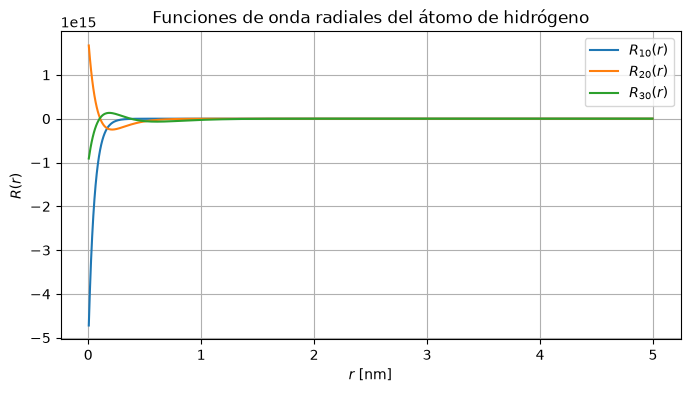

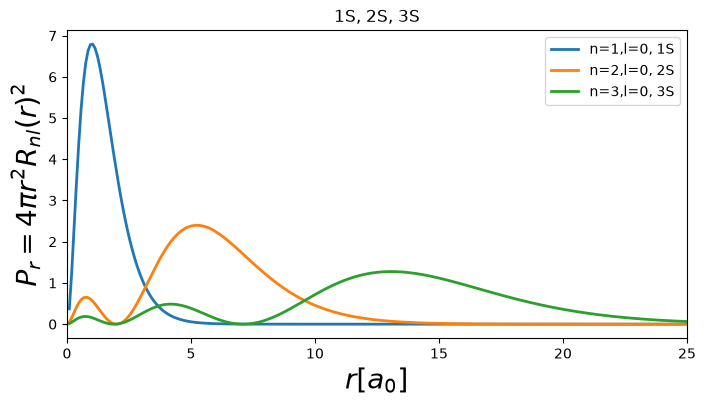

In [3]:
hbar = 1.054571817e-34       # J s
m = 9.1093837e-31            # kg
e = 1.602176634e-19          # C
eps0 = 8.8541878128e-12      # F/m
ke = 1/(4*np.pi*eps0)

r_max = 5e-9 # radio máximo en metros para la visualización de las funciones de onda radiales y las condiciones de frontera
N = 1000

# Creación de una mesh radial uniforme
r = np.linspace(0, r_max, N) 
dr = r[1] - r[0] # diferencia entre puntos de la malla radial
r_i = r[1:-1] # excluyendo los puntos de frontera (r=0 y r=r_max) para not ener singularidades

U = -ke*e**2/r_i # potencial (mirar ecuación anterior en markdown)

# Método de diferencias finitas para construir la matriz Hamiltoniana (visto en clase y en el notebook de Schrodinger)
H = np.zeros((N-2, N-2))
for i in range(N-2):
    H[i,i] = hbar**2/(m*dr**2) + U[i]
    if i > 0: H[i,i-1] = -hbar**2/(2*m*dr**2) # si i > 0, entonces hay un elemento en la diagonal inferior
    if i < N-3: H[i,i+1] = -hbar**2/(2*m*dr**2) # si i < N-3, entonces hay un elemento en la diagonal superior

E, u = np.linalg.eigh(H) # solución del problema de autovalores y autovectores para encontrar energia y func. onda

print("Primeras tres energías:")
for i in range(3):
    print(f"n = {i+1}: E = {E[i]:.6e} J")

# Comparación con la solución analítica para el átomo de hidrógeno
E_analytical = np.array([
    -m*e**4/(2*(4*np.pi*eps0)**2*hbar**2*n**2)
    for n in range(1,4)
])

print("\nEnergías analíticas:")
for i in range(3):
    print(f"n = {i+1}: E = {E_analytical[i]:.6e} J")

for i in range(3):
    u[:,i] /= np.sqrt(np.trapezoid(u[:,i]**2, x=r_i)) # normalización de las funciones de onda radiales

R = u[:,:3]/r_i[:,None] # Conversión de u(r) a R(r) = u(r)/r

plt.figure(figsize=(8,4))
plt.plot(r_i*1e9, R[:,0], label=r'$R_{10}(r)$') # multiplicados por 1e9 para convertir de metros a nanómetros (mejor visualización)
plt.plot(r_i*1e9, R[:,1], label=r'$R_{20}(r)$')
plt.plot(r_i*1e9, R[:,2], label=r'$R_{30}(r)$')
plt.xlabel(r'$r$ [nm]')
plt.ylabel(r'$R(r)$')
plt.title('Funciones de onda radiales del átomo de hidrógeno')
plt.legend()
plt.grid()
plt.show()

# Gráfica en el notebook de schrodinger para comparar
a0 = hbar**2/(m*ke*e**2) # radio de bohr
r_a0 = r_i / a0 # r en unidades de radios de Bohr, para comparar en la misma escala que la solución del notebook referencia
P_r = 4*np.pi*r_i[:,None]**2 * R**2 * a0 # densidad de probabilidad radial P_r=4*pi*r^2*R_nl(r)^2, reescalada a unidades de a0

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(r_a0, P_r[:,0], lw=2, label='n=1,l=0, 1S')
ax.plot(r_a0, P_r[:,1], lw=2, label='n=2,l=0, 2S')
ax.plot(r_a0, P_r[:,2], lw=2, label='n=3,l=0, 3S')

ax.set_xlabel('$r [a_0]$', fontsize=20)
ax.set_ylabel('$P_r=4\\pi r^2R_{nl}(r)^2$', fontsize=20)
ax.set_title('1S, 2S, 3S')
ax.set_xlim(0, 25)
ax.legend()
plt.show()